In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px
import inspect
import time
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import acf, pacf
%matplotlib inline

In [2]:
df = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)
# df.head()

In [3]:
df_pm25_hourly = df[['PM25']].copy()
df_pm25_daily = df_pm25_hourly.resample('D')['PM25'].agg('mean')
df_pm25 = df_pm25_daily
df_pm25

Local Time
2023-01-01     71.541667
2023-01-02     90.375000
2023-01-03     65.916667
2023-01-04     97.166667
2023-01-05     72.500000
                 ...    
2024-12-27     49.958333
2024-12-28     44.167083
2024-12-29     78.597083
2024-12-30    100.277917
2024-12-31     86.299500
Freq: D, Name: PM25, Length: 731, dtype: float64

<Axes: title={'center': 'Mức độ PM2.5 tại Hoàn Kiếm, Dữ liệu hàng ngày'}, xlabel='Thời gian', ylabel='Nồng độ PM2.5'>

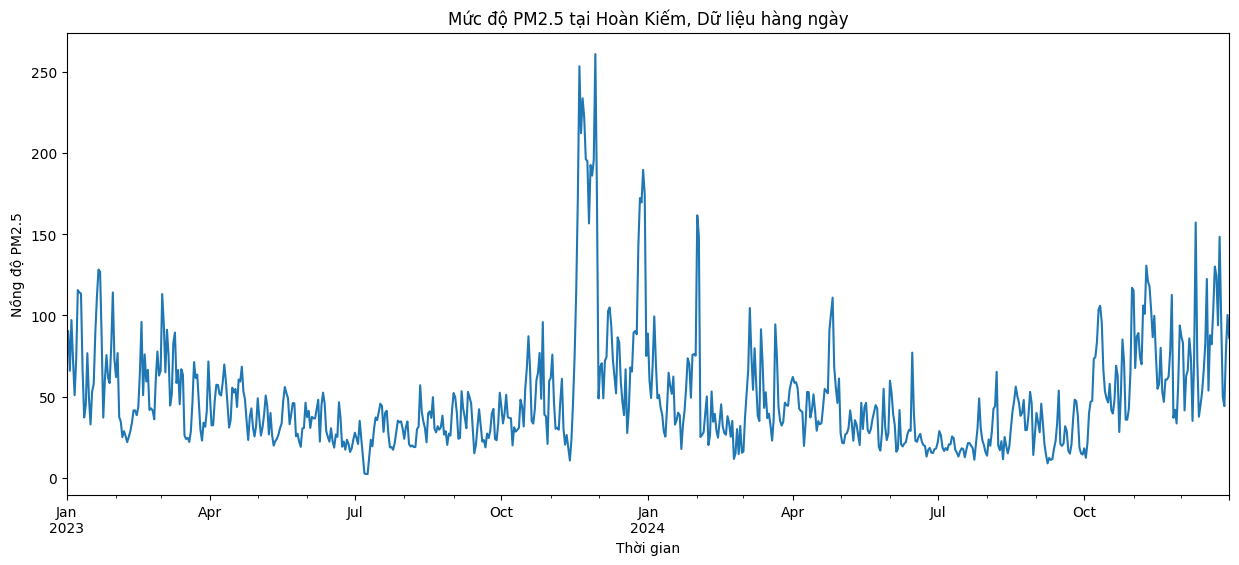

In [4]:
fig, ax = plt.subplots(figsize=(15, 6))
df_pm25.plot(xlabel = "Thời gian",ylabel= "Nồng độ PM2.5", title= "Mức độ PM2.5 tại Hoàn Kiếm, Dữ liệu hàng ngày", ax=ax)
                          

In [5]:
y = df_pm25.astype(float)             # df_pm25 là Series daily bạn vừa tạo
use_log = (y.min() >= 0)
y_log = np.log1p(y) if use_log else y
inv = (np.expm1 if use_log else (lambda x: x))
print("apply log1p:", use_log, "| len:", len(y_log))

apply log1p: True | len: 731


In [7]:
cutoff_test = int(len(df_pm25)* 0.8) 
y_train = y_log[:cutoff_test].copy()
y_test = y_log[cutoff_test:].copy()

y_train= y_train.ffill().bfill(limit=1)


y_test = pd.concat([pd.Series([y_train.iloc[-1]], index=[y_test.index[0]-pd.Timedelta('1D')]), y_test]).ffill().iloc[1:]
print("train:", y_train.index.min(), "->", y_train.index.max(), len(y_train))
print("test :", y_test.index.min(), "->", y_test.index.max(), len(y_test))

train: 2023-01-01 00:00:00 -> 2024-08-06 00:00:00 584
test : 2024-08-07 00:00:00 -> 2024-12-31 00:00:00 147


In [8]:
adf_result = adfuller(y_train)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -6.472784142891778
p-value: 1.3541176364165424e-08
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}


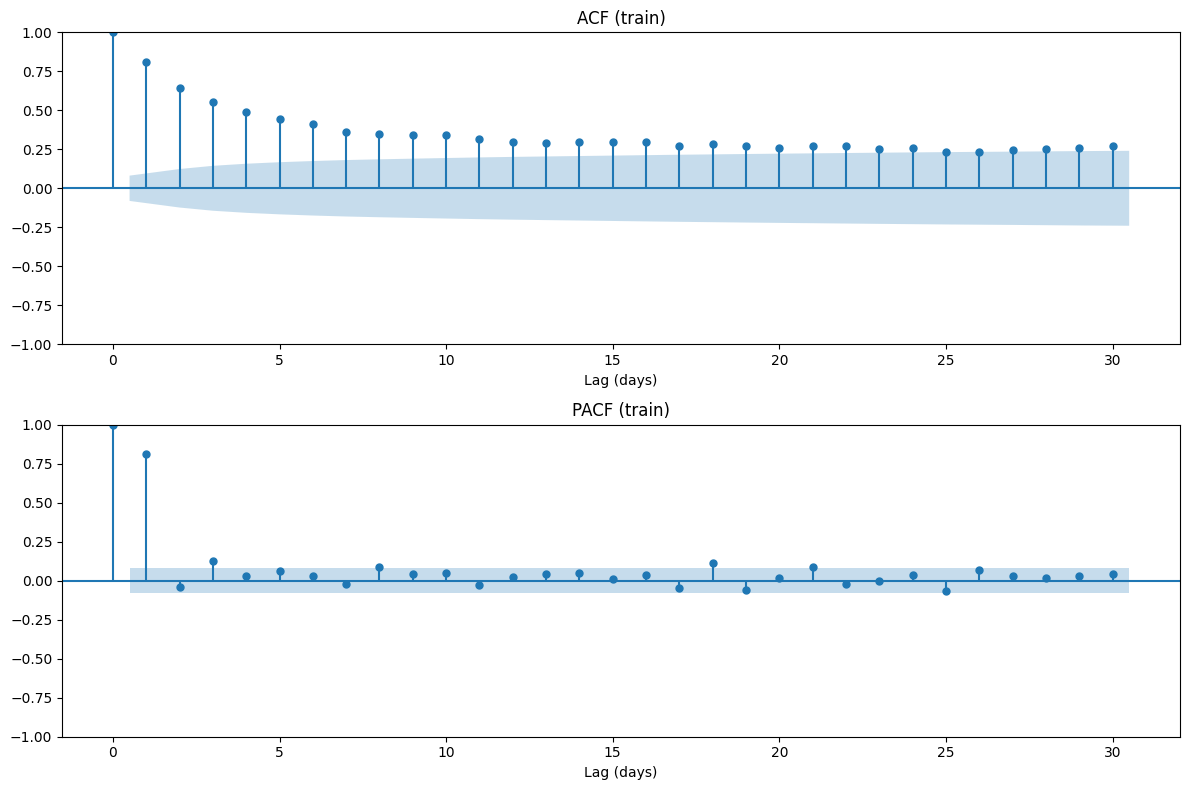

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))  
plot_acf(y_train, lags=30, ax=ax[0])
plot_pacf(y_train, lags=30, ax=ax[1])

ax[0].set_title("ACF (train)")
ax[0].set_xlabel("Lag (days)")
ax[1].set_title("PACF (train)")
ax[1].set_xlabel("Lag (days)")

plt.tight_layout()  # tránh bị chồng chữ
plt.show()

In [10]:
# Tính toán giá trị ACF
acf_values = acf(y_train, nlags=30)
print("ACF Values:")
print(acf_values)
print()

ACF Values:
[1.         0.81191706 0.64586891 0.55526912 0.48920346 0.44516702
 0.41067257 0.36333739 0.34718456 0.34357943 0.34118553 0.31791254
 0.29737907 0.29144575 0.29876942 0.29753263 0.29712844 0.27092175
 0.28333254 0.27374049 0.25666153 0.27065956 0.27005203 0.25407414
 0.2590629  0.23351987 0.23135135 0.24541713 0.25184523 0.25639607
 0.27019469]



In [11]:
pacf_values = pacf(y_train, nlags=30)
print("PACF Values:")
print(pacf_values)

PACF Values:
[ 1.          0.81330971 -0.03953684  0.12531324  0.03094667  0.06433873
  0.0329435  -0.02272509  0.09047775  0.04245197  0.04954868 -0.02842153
  0.02615633  0.04340805  0.05361636  0.01262093  0.03880955 -0.04990022
  0.11976323 -0.06345099  0.01683155  0.09195994 -0.02046109 -0.00233973
  0.03988355 -0.0660193   0.07679213  0.0342739   0.0177798   0.03381398
  0.0470332 ]


In [12]:
# 1. Tính giá trị trung bình của tập huấn luyện (training set)
y_train_mean = y_train.mean()

# 2. Tạo một danh sách dự đoán. 
#    Mô hình cơ sở này chỉ dự đoán "giá trị trung bình" lặp đi lặp lại.
#    Số lần dự đoán bằng đúng số lượng dữ liệu trong tập kiểm thử (test set).
y_pred_baseline = [y_train_mean] * len(y_test)

# 3. Tính Lỗi tuyệt đối trung bình (MAE) của mô hình cơ sở
#    Bằng cách so sánh dữ liệu "thực tế" (df_pm25_test) 
#    với dữ liệu "dự đoán" (df_pm25_pred_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

# 4. In ra giá trị PM2.5 trung bình (đã làm tròn 2 chữ số)
print("Giá trị PM2.5 trung bình:", round(y_train_mean, 2))

# 5. In ra MAE của mô hình cơ sở (đã làm tròn 2 chữ số)
print("MAE của mô hình cơ sở (Baseline MAE):", round(mae_baseline, 2))

Giá trị PM2.5 trung bình: 3.7
MAE của mô hình cơ sở (Baseline MAE): 0.55


In [13]:
import itertools, pandas as pd, time


def aicc(res):
    k, n = res.params.size, res.nobs
    return res.aic + (2*k*(k+1))/max(n-k-1,1)

p_params = range(0,8)
q_params = range(0,4)
d_params = [0,1]

rows=[]
for p,d,q in itertools.product(p_params, d_params, q_params):
    order = (p,d,q)
    try:
        t0=time.time()
        res = ARIMA(y_train, order=order,
                    enforce_stationarity=False, enforce_invertibility=False).fit()
        rows.append({"order":order, "LogL":res.llf, "AIC":res.aic, "AICc":aicc(res), "BIC":res.bic, "fit_s":round(time.time()-t0,2)})
    except Exception as e:
        pass

tbl = pd.DataFrame(rows).sort_values(["AICc","BIC"]).reset_index(drop=True)
tbl.head(10)


,order,LogL,AIC,AICc,BIC,fit_s
0,"(1, 1, 2)",-186.880228,381.760455,381.829540,399.212568,0.05
1,"(2, 1, 2)",-186.314442,382.628883,382.732689,404.444024,0.08
2,"(1, 1, 3)",-186.389085,382.778171,382.881977,404.584683,0.09
3,"(2, 0, 2)",-185.482376,382.964751,383.110332,409.153256,0.22
4,"(3, 0, 2)",-184.617467,383.234934,383.429379,413.788190,0.22
5,"(4, 1, 3)",-183.766378,383.532755,383.783190,418.423175,0.40
6,"(2, 0, 3)",-184.819646,383.639291,383.833736,414.180488,0.31
7,"(5, 1, 2)",-183.837540,383.675080,383.925515,418.551671,0.38
8,"(5, 0, 2)",-183.008059,384.016119,384.329707,423.267841,0.44
9,"(4, 0, 3)",-183.018382,384.036765,384.350354,423.304018,0.47


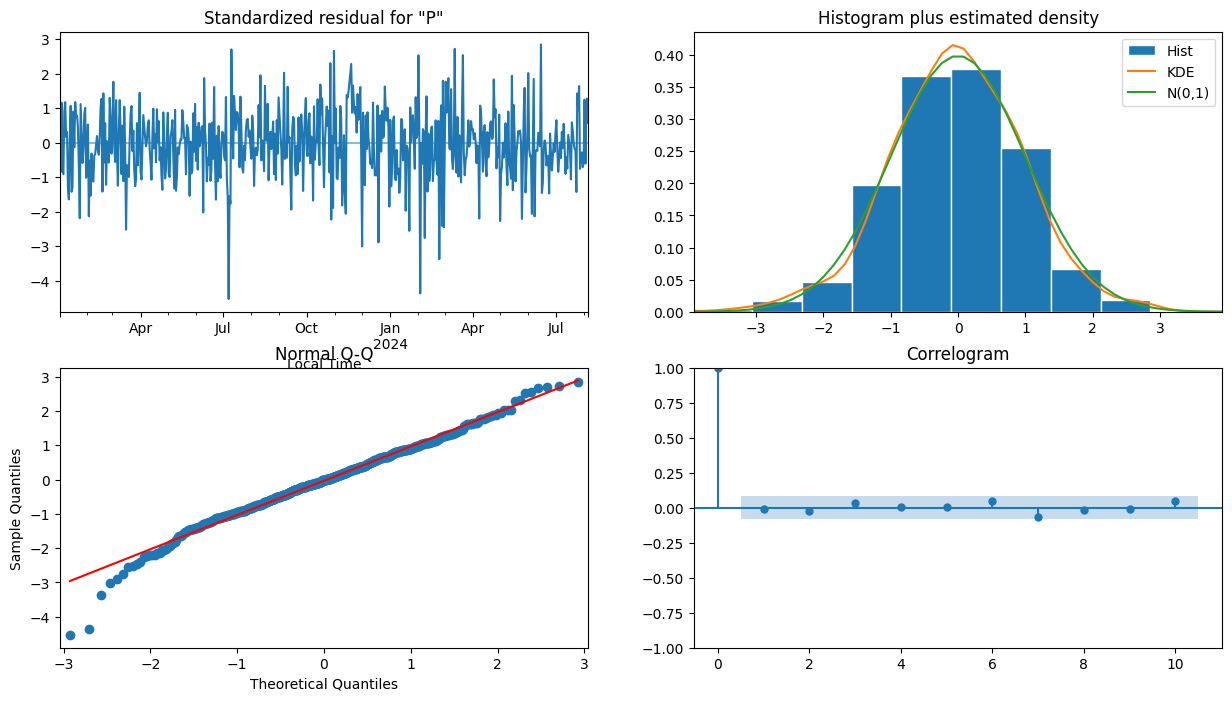

In [14]:
model = ARIMA(y_train, order = (1,1,2))
results = model.fit()
results.plot_diagnostics(figsize=(15,8))
plt.show()

In [15]:
def wf_mae(y, order, init_ratio=0.6):
    n0 = max(10, int(len(y)*init_ratio))
    hist, fut = y.iloc[:n0].copy(), y.iloc[n0:].copy()
    preds=[]
    for i in range(len(fut)):
        m = ARIMA(hist, order=order,
                  enforce_stationarity=False, enforce_invertibility=False).fit()
        preds.append(float(m.forecast(1)))
        hist = pd.concat([hist, fut.iloc[i:i+1]])
    return mean_absolute_error(fut, preds)

top = tbl.head(5).copy()
top["WFV_MAE"] = [wf_mae(y_train, od) for od in top["order"]]
top = top.sort_values(["WFV_MAE","AICc"]).reset_index(drop=True)
best_order = tuple(top.loc[0,"order"])
top, best_order

C:\Users\hungd\AppData\Local\Temp\ipykernel_13672\199332613.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  preds.append(float(m.forecast(1)))
C:\Users\hungd\AppData\Local\Temp\ipykernel_13672\199332613.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  preds.append(float(m.forecast(1)))
C:\Users\hungd\AppData\Local\Temp\ipykernel_13672\199332613.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  preds.append(float(m.forecast(1)))
C:\Users\hungd\AppData\Local\Temp\ipykernel_13672\199332613.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  preds.append(float(m.forecast(1)))
C:\Users\hungd\A

(       order        LogL         AIC        AICc         BIC  fit_s   WFV_MAE
 0  (1, 1, 2) -186.880228  381.760455  381.829540  399.212568   0.05  0.258583
 1  (2, 1, 2) -186.314442  382.628883  382.732689  404.444024   0.08  0.258950
 2  (1, 1, 3) -186.389085  382.778171  382.881977  404.584683   0.09  0.259366
 3  (3, 0, 2) -184.617467  383.234934  383.429379  413.788190   0.22  0.261748
 4  (2, 0, 2) -185.482376  382.964751  383.110332  409.153256   0.22  0.261815,
 (1, 1, 2))

In [16]:
# 1) Forecast trên TEST (cùng thang với y_train), rồi đưa về thang gốc
final = ARIMA(y_train, order=best_order,
              enforce_stationarity=False, enforce_invertibility=False).fit()
fc_te = final.get_forecast(steps=len(y_test)).predicted_mean

yhat_test   = inv(fc_te).rename("forecast")     # dự báo về thang gốc
y_test_goc  = inv(y_test).rename("y_true")      # test về thang gốc
y_train_goc = inv(y_train).rename("y_train")    # train về thang gốc

# 2) Tạo baseline NAIVE *không NaN* (neo = giá trị cuối train; các điểm sau = test liền trước)
import pandas as pd
y_naive = pd.Series(index=y_test_goc.index, dtype=float, name="naive")
y_naive.iloc[0]  = y_train_goc.iloc[-1]                 # điểm đầu test
y_naive.iloc[1:] = y_test_goc.iloc[:-1].to_numpy()      # trượt 1 bước

# 3) Gộp – căn chỉ số – loại mọi NaN một lần cho chắc
df_eval = pd.concat([y_test_goc, yhat_test, y_naive], axis=1)
df_eval = df_eval.astype(float).dropna()  # nếu còn NaN do méo index/biên, sẽ bị loại ở đây

# 4) Tính MAE
from sklearn.metrics import mean_absolute_error
mae_mean  = mean_absolute_error(df_eval["y_true"], 
                                [y_train_goc.mean()]*len(df_eval))
mae_naive = mean_absolute_error(df_eval["y_true"], df_eval["naive"])
mae_final = mean_absolute_error(df_eval["y_true"], df_eval["forecast"])
print(f"TEST MAE | Mean: {mae_mean:.2f} | Naive: {mae_naive:.2f} | ARIMA{best_order}: {mae_final:.2f}")




TEST MAE | Mean: 26.12 | Naive: 16.41 | ARIMA(1, 1, 2): 35.21


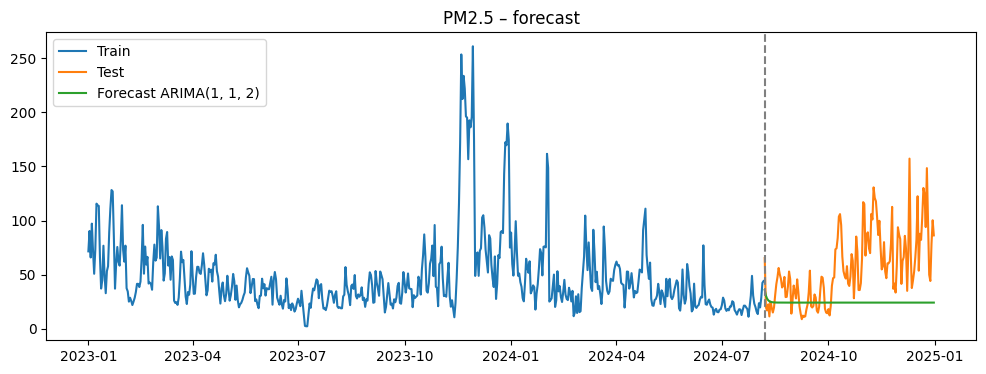

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(y_train_goc.index, y_train_goc, label="Train")
plt.plot(y_test_goc.index,  y_test_goc,  label="Test")
plt.plot(yhat_test.index,   yhat_test,   label=f"Forecast ARIMA{best_order}")
try:
    plt.plot(yhat_sar.index, yhat_sar, label=f"SARIMA {best_sod}")
except: pass
plt.axvline(y_test_goc.index[0], color='gray', ls='--')
plt.legend(); plt.title("PM2.5 – forecast"); plt.show()


In [18]:
history = y_train.copy()
preds_t = []                           # dự báo trên THANG TRANSFORM
for i in range(len(y_test)):
    m = ARIMA(history, order=best_order,
              enforce_stationarity=False, enforce_invertibility=False).fit()
    preds_t.append(float(m.forecast(1)))        # dự báo 1 bước
    # cập nhật bằng GIÁ TRỊ THỰC của test tại bước hiện tại
    history = pd.concat([history, y_test.iloc[i:i+1]])

# đưa dự báo về thang gốc để so sánh/vẽ
yhat_wf = pd.Series(preds_t, index=y_test.index)
yhat_wf_goc = inv(yhat_wf)
y_test_goc  = inv(y_test)
y_train_goc = inv(y_train)

C:\Users\hungd\AppData\Local\Temp\ipykernel_13672\1503133922.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  preds_t.append(float(m.forecast(1)))        # dự báo 1 bước
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\hungd\AppData\

Walk-forward MAE: 15.35


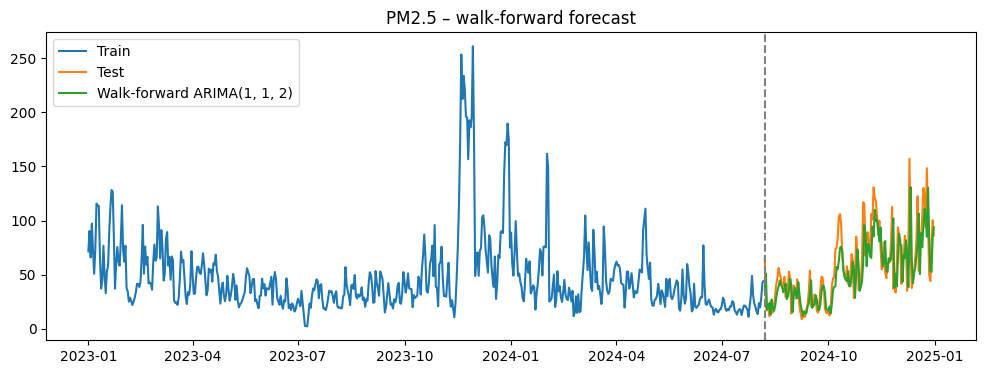

In [19]:
mae_wf = mean_absolute_error(y_test_goc, yhat_wf_goc)
print(f"Walk-forward MAE: {mae_wf:.2f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(y_train_goc, label="Train")
plt.plot(y_test_goc,  label="Test")
plt.plot(yhat_wf_goc, label=f"Walk-forward ARIMA{best_order}")
plt.axvline(y_test_goc.index[0], color="gray", ls="--")
plt.title("PM2.5 – walk-forward forecast"); plt.legend(); plt.show()

In [20]:
def wf_forecast_with_ci(y_tr, y_te, order):
    hist = y_tr.copy()
    preds, lo, hi = [], [], []
    for i in range(len(y_te)):
        m = ARIMA(hist, order=order,
                  enforce_stationarity=False, enforce_invertibility=False).fit()
        f = m.get_forecast(1)
        preds.append(float(f.predicted_mean))
        ci = f.conf_int(alpha=0.05).iloc[0]  # 95%
        lo.append(float(ci[0])); hi.append(float(ci[1]))
        hist = pd.concat([hist, y_te.iloc[i:i+1]])
    out = pd.DataFrame({"pred": preds, "lo": lo, "hi": hi}, index=y_te.index)
    return out

wf_t = wf_forecast_with_ci(y_train, y_test, best_order)
yhat_wf_goc = inv(wf_t["pred"])
lo_goc, hi_goc = inv(wf_t["lo"]), inv(wf_t["hi"])

C:\Users\hungd\AppData\Local\Temp\ipykernel_13672\4274991666.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  preds.append(float(f.predicted_mean))
C:\Users\hungd\AppData\Local\Temp\ipykernel_13672\4274991666.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lo.append(float(ci[0])); hi.append(float(ci[1]))
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided,

In [21]:
m = 7
y_naive = pd.Series(index=y_test.index, dtype=float)
y_naive.iloc[0]  = inv(y_train).iloc[-1]
y_naive.iloc[1:] = inv(y_test).iloc[:-1].to_numpy()

y_snaive = pd.Series(index=y_test.index, dtype=float)
y_snaive.iloc[:m]  = inv(y_train).iloc[-m:].to_numpy()
y_snaive.iloc[m:]  = inv(y_test).iloc[:-m].to_numpy()


In [22]:
# Đưa về thang gốc
y_tr_goc = inv(y_train)
y_te_goc = inv(y_test)

# Hàm RMSE - viết thủ công để tránh lỗi 'squared=False'
def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

# Hàm sMAPE (Symmetric Mean Absolute Percentage Error)
def smape(y, yhat): 
    y, yhat = np.array(y), np.array(yhat)
    return np.mean(2 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat) + 1e-8)) * 100

# Tính các chỉ số
mae_wf   = mean_absolute_error(y_te_goc, yhat_wf_goc)
mae_mean = mean_absolute_error(y_te_goc, [y_tr_goc.mean()] * len(y_te_goc))
mae_nv   = mean_absolute_error(y_te_goc, y_naive)
mae_snv  = mean_absolute_error(y_te_goc, y_snaive)

# In kết quả
print(f"MAE | Mean:{mae_mean:.2f}  Naive:{mae_nv:.2f}  S-Naive:{mae_snv:.2f}  ARIMA{best_order}:{mae_wf:.2f}")
print(f"RMSE ARIMA: {rmse(y_te_goc, yhat_wf_goc):.2f} | sMAPE ARIMA: {smape(y_te_goc, yhat_wf_goc):.1f}%")

MAE | Mean:26.12  Naive:16.41  S-Naive:26.98  ARIMA(1, 1, 2):15.35
RMSE ARIMA: 21.38 | sMAPE ARIMA: 28.7%


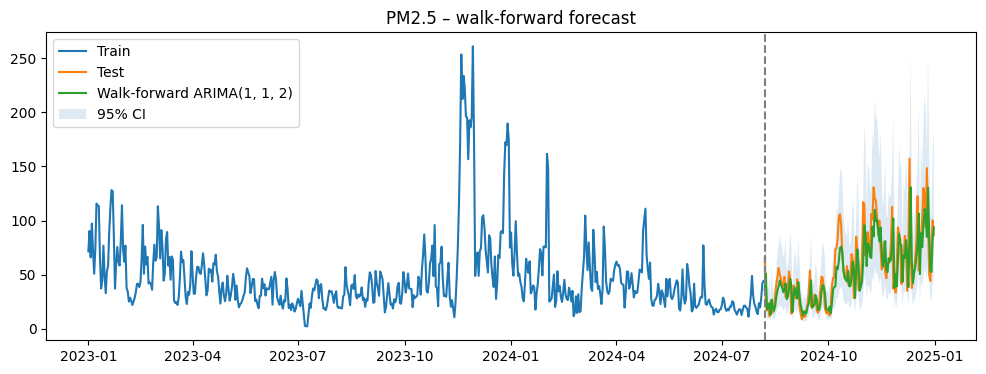

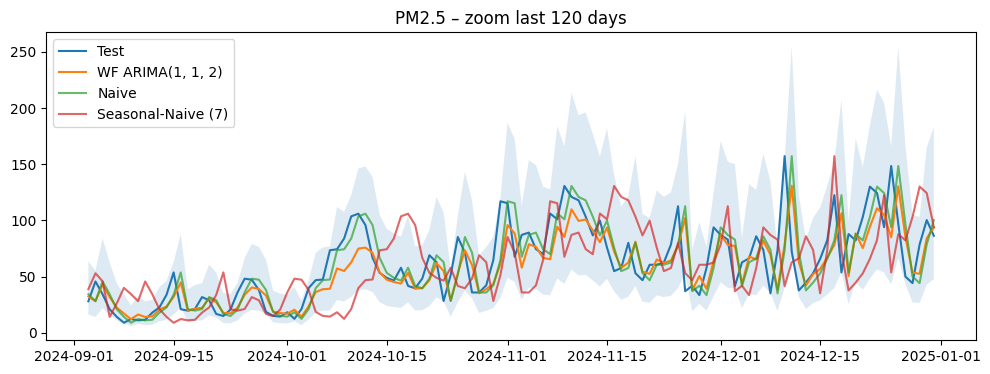

In [23]:
plt.figure(figsize=(12,4))
plt.plot(y_tr_goc, label="Train")
plt.plot(y_te_goc, label="Test")
plt.plot(yhat_wf_goc, label=f"Walk-forward ARIMA{best_order}")
plt.fill_between(y_te_goc.index, lo_goc, hi_goc, alpha=0.15, label="95% CI")
plt.axvline(y_te_goc.index[0], color="gray", ls="--")
plt.title("PM2.5 – walk-forward forecast"); plt.legend(); plt.show()

# Zoom 120 ngày cuối
last = 120
plt.figure(figsize=(12,4))
plt.plot(y_te_goc.iloc[-last:], label="Test")
plt.plot(yhat_wf_goc.iloc[-last:], label=f"WF ARIMA{best_order}")
plt.plot(y_naive.iloc[-last:], label="Naive", alpha=0.7)
plt.plot(y_snaive.iloc[-last:], label="Seasonal-Naive (7)", alpha=0.7)
plt.fill_between(y_te_goc.index[-last:], lo_goc.iloc[-last:], hi_goc.iloc[-last:], alpha=0.15)
plt.title("PM2.5 – zoom last 120 days"); plt.legend(); plt.show()

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox
m_fit = ARIMA(pd.concat([y_train, y_test]), order=best_order).fit()  # fit toàn bộ để xem resid chung
pval = float(acorr_ljungbox(m_fit.resid.dropna(), lags=[12], return_df=True)["lb_pvalue"].iloc[0])
print("Ljung–Box p(12):", round(pval,4))

Ljung–Box p(12): 0.934


c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hungd\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
